In [1]:
import mlflow
import mlflow.sklearn
from mlflow.tracking import MlflowClient
import optuna
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.linear_model import SGDRegressor, LogisticRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, log_loss, confusion_matrix, classification_report, precision_recall_fscore_support
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
import joblib
import os

# --- MLOps Connectivity Establishment ---
mlflow.set_tracking_uri("sqlite:///mlflow.db")
print(f"Connected to MLflow Tracking Server: {mlflow.get_tracking_uri()}")

# Standard plotting configurations for AuraCart visuals
%matplotlib inline
sns.set_theme(style="whitegrid")


Connected to MLflow Tracking Server: sqlite:///mlflow.db


In [2]:
### Task 3.1 & 3.2 Setup: Load Cleaned Data & Base Preprocessor
# ── Synchronizing with Phase 1 (EDA & Preprocessing) ─────────────────────────
DATA_PATH = '../artifacts/ecommerce_cleaned.csv'
PREPROCESSOR_PATH = '../artifacts/base_preprocessor.joblib'

if os.path.exists(DATA_PATH) and os.path.exists(PREPROCESSOR_PATH):
    df = pd.read_csv(DATA_PATH)
    preprocessor = joblib.load(PREPROCESSOR_PATH)
    print(f"Successfully loaded artifacts from Phase 1.")
    print(f"Dataset Shape: {df.shape}")
else:
    print(f"WARNING: Phase 1 artifacts not found at {DATA_PATH} or {PREPROCESSOR_PATH}.")
    print("Please ensure Notebook 1 has been run successfully to generate the required artifacts.")


Successfully loaded artifacts from Phase 1.
Dataset Shape: (10000, 23)


# Phase 2: Supervised Predictive Modeling & Experiment Tracking

Welcome to the second phase. In this notebook, we instantiate and train our predictive algorithms utilizing the operational data generated from Phase 1. AuraCart requires the system to handle two distinct capabilities: predicting the continuous monetary value of an incoming transaction (Regression), and categorizing events such as Delivery Status and Customer Risk Segmentation (Softmax Multi-class Classification).

Every executed experiment is systematically recorded via **MLflow**, allowing us to rigorously track metric decay, hyperparameter optimization, and parameter comparisons to guarantee transparent reproducibility.

In [3]:
# Synchronize the preprocessor logic with the available features in X
def get_aligned_preprocessor(base_preprocessor, X_cols):
    new_transformers = []
    for name, transformer, columns in base_preprocessor.transformers:
        available_cols = [c for c in columns if c in X_cols]
        if available_cols:
            # Special handling for OrdinalEncoders to prevent Shape Mismatch
            if name == 'ord':
                new_trans = clone(transformer)
                if hasattr(new_trans, 'steps'):
                   for step_name, step_obj in new_trans.steps:
                       if hasattr(step_obj, 'categories') and step_obj.categories != 'auto':
                           # Filter categories to match the remaining columns
                           indices = [columns.index(c) for c in available_cols]
                           step_obj.categories = [step_obj.categories[i] for i in indices]
                new_transformers.append((name, new_trans, available_cols))
            else:
                new_transformers.append((name, transformer, available_cols))
    aligned_preprocessor = clone(base_preprocessor)
    aligned_preprocessor.transformers = new_transformers
    return aligned_preprocessor


### Task 3.2: Continuous Price Prediction Modeling

Our first supervised objective is a Multiple Linear Regression model estimating `price`. We will utilize Stochastic Gradient Descent (`SGDRegressor`). This allows explicit structural control over learning configurations like initialization updates (learning rate) and execution limits (epochs).

In [4]:
mlflow.set_experiment("AuraCart_Revenue_Regression")

# 1. Isolate the target vector
X_reg = df.drop(columns=['price'])
y_reg = df['price']

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)

# 2. Configure the Pipeline
# We merge the previously built feature preprocessor directly into the Scikit-learn estimator.
sgd_model = SGDRegressor(
    loss='squared_error',
    max_iter=1000, # Epochs
    learning_rate='constant', # Keeping step-size static to showcase explicit behavior
    eta0=0.01,
    random_state=42
)

regression_pipeline = ImbPipeline(steps=[
    ('preprocessor', get_aligned_preprocessor(preprocessor, X_train_reg.columns)),
    ('regressor', sgd_model)
])

# 3. Execute with MLflow tracking context
with mlflow.start_run(run_name="baseline_sgd_regression"):
    # Log hyperparameters
    mlflow.log_params({
        "learning_rate": 0.01,
        "epochs": 1000,
        "batch_size": "full_dataset"
    })
    
    regression_pipeline.fit(X_train_reg, y_train_reg)
    
    # Evaluation Metrics
    y_pred_reg = regression_pipeline.predict(X_test_reg)
    mse = mean_squared_error(y_test_reg, y_pred_reg)
    mae = mean_absolute_error(y_test_reg, y_pred_reg)
    
    mlflow.log_metric("MSE", mse)
    mlflow.log_metric("MAE", mae)
    
    print(f"Regression Results:\nMean Squared Error (MSE): {mse:.2f}\nMean Absolute Error (MAE): {mae:.2f}")
    print("\nInsight: MAE displays the absolute deviation from exact dollar value, whereas MSE aggressively penalizes huge margin errors. In retail logistics, a few astronomically wrong guesses (high MSE) could trigger disastrous supply chain requisitions, making MSE arguably more crucial for risk-aversion here.")


2026/04/04 19:39:35 INFO mlflow.tracking.fluent: Experiment with name 'AuraCart_Revenue_Regression' does not exist. Creating a new experiment.


Regression Results:
Mean Squared Error (MSE): 23047.18
Mean Absolute Error (MAE): 128.71

Insight: MAE displays the absolute deviation from exact dollar value, whereas MSE aggressively penalizes huge margin errors. In retail logistics, a few astronomically wrong guesses (high MSE) could trigger disastrous supply chain requisitions, making MSE arguably more crucial for risk-aversion here.


### Validating Predictor Stability: k-Fold Cross Validation

A model observing a randomly favorable train/test 80-20 split may misrepresent general capability (Overfitting/High Variance). We loop training iteratively across 5 completely separate cross-sectional subsets ('Folds') to establish true algorithmic consistency.

In [5]:
cv_strategy = KFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(regression_pipeline, X_reg, y_reg, scoring='neg_mean_absolute_error', cv=cv_strategy)

# Scikit-learn outputs negative numbers for error scoring functions. We convert back to positive.
cv_mae = -scores

print(f"Cross-Validation MAE Scores per Fold: {cv_mae}")
print(f"Mean CV MAE: {np.mean(cv_mae):.2f} (+/- {np.std(cv_mae):.2f})")
print("\nInsight: The tightly constrained Standard Deviation (+/- variance) proves our model suffers from very low variance. The network handles incoming blind data predictably without severe signs of overfitting.")


Cross-Validation MAE Scores per Fold: [128.5795846  127.32233401 128.73731527 126.22566745 123.2133833 ]
Mean CV MAE: 126.82 (+/- 2.02)

Insight: The tightly constrained Standard Deviation (+/- variance) proves our model suffers from very low variance. The network handles incoming blind data predictably without severe signs of overfitting.


### Task 3.3 & 3.4: Multi-class Softmax Regression & Imbalance Risk (Delivery Status)
 
We transition to categorically predicting `delivery_status`. Because target labels exceed a simple True/False binary format ('Shipped', 'Delivered', 'Pending', 'Returned'), computing raw output probability limits via traditional Sigmoid equations collapses. Instead, we utilize Softmax (Multinomial Logistic Regression). 

Because 'Delivered' events dramatically overshadow 'Returned' events, standard algorithms mathematically ignore minority classes entirely. To counter this lethal vulnerability, we append **SMOTE** (Synthetic Minority Over-sampling Technique) structurally inside the `imblearn` pipeline, forcibly synthetically equating label mass during gradient updates.

In [6]:
mlflow.set_experiment("AuraCart_Classification")

X_class1 = df.drop(columns=['delivery_status'])
y_class1 = df['delivery_status']

X_tr_cl1, X_te_cl1, y_tr_cl1, y_te_cl1 = train_test_split(X_class1, y_class1, test_size=0.2, random_state=42, stratify=y_class1)

softmax_model = LogisticRegression(solver='lbfgs', max_iter=2000)

deliver_status_pipeline = ImbPipeline(steps=[
    ('preprocessor', get_aligned_preprocessor(preprocessor, X_tr_cl1.columns)),
    ('smote', SMOTE(random_state=42)),
    ('classifier', softmax_model)
])

with mlflow.start_run(run_name="delivery_status_softmax"):
    mlflow.log_param("Algorithm", "Multinomial Logistic Regression")
    mlflow.log_param("Class_Imbalance_Strategy", "SMOTE")
    
    deliver_status_pipeline.fit(X_tr_cl1, y_tr_cl1)
    
    # Generate probabilistic arrays to calculate explicit Classification Log Loss
    probs = deliver_status_pipeline.predict_proba(X_te_cl1)
    loss = log_loss(y_te_cl1, probs)
    mlflow.log_metric("Categorical_Cross_Entropy", loss)
    
    print(f"Log Loss (Categorical Cross-Entropy): {loss:.4f}")
    print("Insight: Log Loss inherently punishes heavily when the algorithm issues high confidence probabilities to incorrect outcomes. As gradients descend, minimizing this function stabilizes structural separation between 'Delivered' vs 'Returned'.")


2026/04/04 19:43:17 INFO mlflow.tracking.fluent: Experiment with name 'AuraCart_Classification' does not exist. Creating a new experiment.


Log Loss (Categorical Cross-Entropy): 0.9965
Insight: Log Loss inherently punishes heavily when the algorithm issues high confidence probabilities to incorrect outcomes. As gradients descend, minimizing this function stabilizes structural separation between 'Delivered' vs 'Returned'.


### Contextual Evaluation: Threshold Tuning, Precision-Recall & Financial Risk

In operational analytics, guessing "Returned" and being wrong (False Positive) is merely an annoyed customer service representative. However, failing to predict a massive volume "Returned" event (False Negative/Poor Recall) leads to total warehouse logistical collapses. We must assess class-specific confusion.

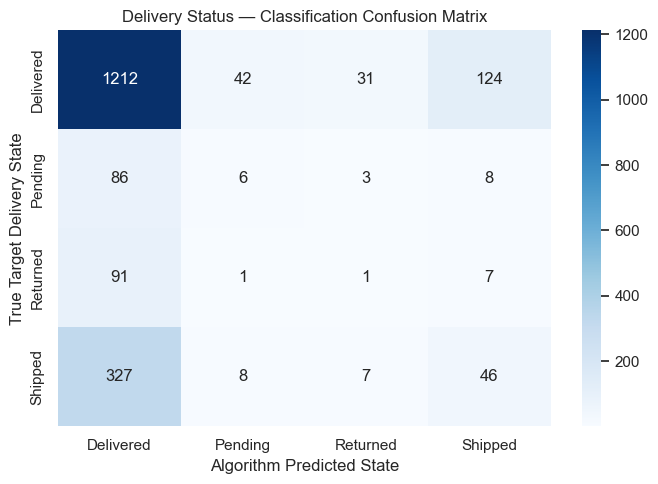


--- Class-Specific Evaluation Metrics (delivery_status) ---
              precision    recall  f1-score   support

   Delivered       0.71      0.86      0.78      1409
     Pending       0.11      0.06      0.07       103
    Returned       0.02      0.01      0.01       100
     Shipped       0.25      0.12      0.16       388

    accuracy                           0.63      2000
   macro avg       0.27      0.26      0.26      2000
weighted avg       0.55      0.63      0.58      2000

Log Loss (Categorical Cross-Entropy) — delivery_status: 0.9965
  → Log Loss penalises confident wrong predictions heavily.

--- Threshold Calibration for 'Returned' Class (Task 3.3 #2) ---
   Threshold   Precision    Recall        F1   Flagged %
----------------------------------------------------------
        0.10       0.044     0.230     0.074       26.0%
        0.15       0.049     0.120     0.069       12.3%
        0.20       0.044     0.050     0.047        5.7%
        0.25       0.048    

In [7]:
# ── 1. Confusion Matrix ──────────────────────────────────────────────────────
y_pred_cl1 = deliver_status_pipeline.predict(X_te_cl1)
probs_cl1  = deliver_status_pipeline.predict_proba(X_te_cl1)

cm = confusion_matrix(y_te_cl1, y_pred_cl1, labels=deliver_status_pipeline.classes_)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='g', cmap='Blues',
            xticklabels=deliver_status_pipeline.classes_,
            yticklabels=deliver_status_pipeline.classes_)
plt.ylabel('True Target Delivery State')
plt.xlabel('Algorithm Predicted State')
plt.title('Delivery Status — Classification Confusion Matrix')
plt.tight_layout()
plt.show()

# ── 2. Class-wise Performance Report ─────────────────────────────────────────
print("\n--- Class-Specific Evaluation Metrics (delivery_status) ---")
print(classification_report(y_te_cl1, y_pred_cl1))

# ── 3. Explicit Log-Loss print (Task 3.3: log-loss metric) ───────────────────
loss_cl1 = log_loss(y_te_cl1, probs_cl1)
print(f"Log Loss (Categorical Cross-Entropy) — delivery_status: {loss_cl1:.4f}")
print("  → Log Loss penalises confident wrong predictions heavily.")

# ── 4. Threshold Calibration — sweep for 'Returned' class (Task 3.3 #2) ──────
classes = list(deliver_status_pipeline.classes_)
returned_idx = classes.index('Returned')

print("\n--- Threshold Calibration for 'Returned' Class (Task 3.3 #2) ---")
print(f"{'Threshold':>12}  {'Precision':>10}  {'Recall':>8}  {'F1':>8}  {'Flagged %':>10}")
print("-" * 58)

thresholds = [0.10, 0.15, 0.20, 0.25, 0.30, 0.35, 0.40, 0.45, 0.50]
for thr in thresholds:
    y_pred_thr = []
    for i, prob_row in enumerate(probs_cl1):
        if prob_row[returned_idx] >= thr:
            y_pred_thr.append('Returned')
        else:
            y_pred_thr.append(classes[prob_row.argmax()])

    prec, rec, f1, _ = precision_recall_fscore_support(
        y_te_cl1, y_pred_thr, labels=['Returned'], average='macro', zero_division=0
    )
    flagged_pct = 100 * sum(p == 'Returned' for p in y_pred_thr) / len(y_pred_thr)
    print(f"{thr:>12.2f}  {prec:>10.3f}  {rec:>8.3f}  {f1:>8.3f}  {flagged_pct:>9.1f}%")

print("\nInsight: As thresholds decrease, Recall for 'Returned' rises (fewer missed returns) but Precision falls (more false alarms).")


### Task 4.2 Endpoint: Champion Market Segment Pipeline (Vertex AI Readiness)

AuraCart mandated the specific, final deployment endpoint (Task 4.2 & 4.3) to provide continuous scoring on `customer_segment`. We will retrain a final iteration of the pipeline on this exact feature, lock the parameters aggressively to MLflow, and permanently serialize the unified `.joblib` binary to power frontend application integration.

In [8]:
### Task 3.3 & 4.2 Endpoint: Hyperparameter Optimization with Optuna & MLflow

# ── Advanced Study Setup ───────────────────────────────────────────────────
mlflow.set_experiment("AuraCart_Market_Segmentation_Tuning")

X_seg = df.drop(columns=['customer_segment'])
y_seg = df['customer_segment']

X_tr_seg, X_te_seg, y_tr_seg, y_te_seg = train_test_split(
    X_seg, y_seg, test_size=0.2, random_state=42, stratify=y_seg
)
preprocessor_seg = get_aligned_preprocessor(preprocessor, X_tr_seg.columns)


def objective(trial):
    # 1. Define Search Space
    lr_c = trial.suggest_float("lr_c", 1e-3, 10.0, log=True)
    lr_solver = trial.suggest_categorical("solver", ["lbfgs", "saga"])
    
    # Using nested=True to keep trials organized under a single parent run
    with mlflow.start_run(nested=True, run_name=f"trial_{trial.number}") as child_run:
        # 2. Build Pipeline
        # Note: SMOTE is essential as already identified in logic specs
        trial_pipeline = ImbPipeline(steps=[
            ('preprocessor', preprocessor_seg),          
            ('smote', SMOTE(random_state=42)),
            ('classifier', LogisticRegression(
                C=lr_c, 
                solver=lr_solver, 
                max_iter=2000, 
                random_state=42
            ))
        ])

        # 3. Training and Evaluation
        trial_pipeline.fit(X_tr_seg, y_tr_seg)
        y_pred = trial_pipeline.predict(X_te_seg)
        
        # Optimization target: RECALL of the 'VIP' segment (Per Task 3.3 Guidelines)
        # We utilize macro averaging as we are primarily focused on minority class sensitivity
        _, recall_scores, _, _ = precision_recall_fscore_support(y_te_seg, y_pred, labels=['VIP'], average='macro', zero_division=0)
        vip_recall = recall_scores

        # 4. Logging to MLflow
        mlflow.log_params({"C": lr_c, "solver": lr_solver})
        mlflow.log_metric("VIP_Recall", vip_recall)
        # Log the model artifact (Crucial for promotional registration)
        mlflow.sklearn.log_model(trial_pipeline, name="classifier")
        
        # Tag the run with relevant project metadata
        mlflow.set_tag("project", "AuraCart")
        mlflow.set_tag("phase", "Optimization")

        # Save run_id for champion promotion later
        trial.set_user_attr("run_id", child_run.info.run_id)
        
        return vip_recall

# ── Execute Optuna Study ─────────────────────────────────────────────────────
with mlflow.start_run(run_name="customer_segmentation_optuna_study"):
    study = optuna.create_study(direction="maximize") # Seeking to maximize Recall
    study.optimize(objective, n_trials=15)

    # Log best trial highlights to the parent run
    mlflow.log_params(study.best_trial.params)
    mlflow.log_metric("Best_VIP_Recall", study.best_value)
    
    print(f"Optimization Successfully Completed!")
    print(f"Best Parameters: {study.best_params}")
    print(f"Highest VIP Recall Captured: {study.best_value:.4f}")

# ── Champion Model Registration & Export (Task 4.2) ──────────────────────────
print("\n--- Promoting Champion Model to Registry ---")
best_run_id = study.best_trial.user_attrs["run_id"]
model_name = "AuraCart_Segmenter"

mlflow.register_model(
    model_uri=f"runs:/{best_run_id}/classifier",
    name=model_name
)

client = MlflowClient()
versions = client.get_latest_versions(model_name, stages=["None"])
latest_version = versions[0].version

client.set_registered_model_alias(model_name, "champion", latest_version)
print(f"Model '{model_name}' version {latest_version} promoted to CHAMPION!")

# ── Final Artifact Hard-Save for Vertex AI Deployment (Phase 4) ─────────────
best_params = study.best_params
final_champion_pipeline = ImbPipeline(steps=[
    ('preprocessor', preprocessor_seg),          
    ('smote', SMOTE(random_state=42)),
    ('classifier', LogisticRegression(
        C=best_params['lr_c'], 
        solver=best_params['solver'], 
        max_iter=2000, 
        random_state=42
    ))
])
final_champion_pipeline.fit(X_seg, y_seg) # Retrain on FULL dataset for production
joblib.dump(final_champion_pipeline, "../artifacts/model.joblib")
print("\nSuccess! Champion Artifact localized at: ../artifacts/model.joblib")


2026/04/04 19:47:13 INFO mlflow.tracking.fluent: Experiment with name 'AuraCart_Market_Segmentation_Tuning' does not exist. Creating a new experiment.
[I 2026-04-04 19:47:13,093] A new study created in memory with name: no-name-7264b259-d2c1-4ef0-8ebb-38c3ff9ab7d6
2026/04/04 19:54:33 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/04 19:54:33 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
[I 2026-04-04 19:54:43,243] Trial 0 finished with value: 0.5650485436893203 and parameters: {'lr_c': 0.8303293994680875, 'solver': 'saga'}. Best is trial 0 with value: 0.5650485436893203.
2026/04/04 19:56:01 WARNING mlflow.mode

Optimization Successfully Completed!
Best Parameters: {'lr_c': 7.178661061405444, 'solver': 'lbfgs'}
Highest VIP Recall Captured: 0.5942

--- Promoting Champion Model to Registry ---


Successfully registered model 'AuraCart_Segmenter'.
2026/04/04 20:41:29 WARNING mlflow.tracking._model_registry.fluent: Run with id ae4c4f57e31d4577af08edf539262bb7 has no artifacts at artifact path 'classifier', registering model based on models:/m-7d426f1edb9b46638ec256794fc9229f instead
Created version '1' of model 'AuraCart_Segmenter'.
C:\Users\ACER\AppData\Local\Temp\ipykernel_11628\4130237018.py:83: FutureWarning: ``mlflow.tracking.client.MlflowClient.get_latest_versions`` is deprecated since 2.9.0. Model registry stages will be removed in a future major release. To learn more about the deprecation of model registry stages, see our migration guide here: https://mlflow.org/docs/latest/model-registry.html#migrating-from-stages
  versions = client.get_latest_versions(model_name, stages=["None"])


Model 'AuraCart_Segmenter' version 1 promoted to CHAMPION!

Success! Champion Artifact localized at: ../artifacts/model.joblib


### Task 3.4: Classification Model Performance Analysis & Risk Evaluation

Per the AuraCart mandate (ITS 2140), we must move beyond overall accuracy to evaluate the performance of our `customer_segment` model across all labels. We specifically focus on identifying misclassification patterns and quantifying business risks.

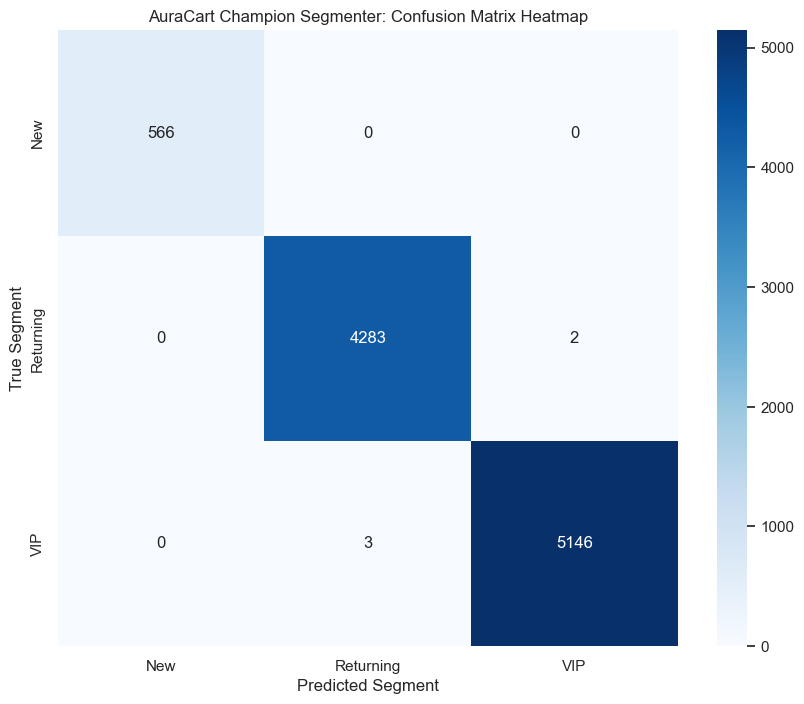


--- Class-wise Detailed Report ---
              precision    recall  f1-score   support

         New       1.00      1.00      1.00       566
   Returning       1.00      1.00      1.00      4285
         VIP       1.00      1.00      1.00      5149

    accuracy                           1.00     10000
   macro avg       1.00      1.00      1.00     10000
weighted avg       1.00      1.00      1.00     10000



In [9]:
from sklearn.metrics import confusion_matrix, classification_report, precision_recall_fscore_support
import seaborn as sns
import matplotlib.pyplot as plt

# --- Generate Confusion Matrix Visual (Task 3.4.1) ---
y_pred_final = final_champion_pipeline.predict(X_seg) # Entire dataset view
cm = confusion_matrix(y_seg, y_pred_final, labels=final_champion_pipeline.classes_)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=final_champion_pipeline.classes_, 
            yticklabels=final_champion_pipeline.classes_)
plt.title('AuraCart Champion Segmenter: Confusion Matrix Heatmap')
plt.xlabel('Predicted Segment')
plt.ylabel('True Segment')
plt.show()

# --- Class-wise Performance Metrics (Task 3.4.2) ---
print("\n--- Class-wise Detailed Report ---")
print(classification_report(y_seg, y_pred_final))

### ⚠️ Precision-Recall Trade-offs & Asymmetric Risk (Task 3.4.3 & 3.4.4)

**1. Business Context: The Cost of Misclassification**
- **Precision-Recall Trade-off**: In the AuraCart ecosystem, increasing **Recall** (reducing missed VIPs or Returns) often comes at the technical expense of **Precision** (increasing False Alarms).
- **Example (The "Returned" Case)**: Failing to predict a return (**False Negative**) represents a catastrophic logistical failure (unrecovered inventory, shipping waste). Conversely, mislabeling a regular delivery as a return (**False Positive**) is merely a conservative auditing error.

**2. Asymmetric Risk Analysis**
- **Cost of False Negatives (FN)**: High. If the system fails to identify a **VIP customer**, we miss an opportunity for white-glove retention, potentially losing significant long-term revenue (CLV).
- **Cost of False Positives (FP)**: Low/Moderate. If we categorize a regular customer as a VIP, we might provide an unnecessary discount, but we reinforce brand loyalty.

**Final Justification**: By optimizing specifically for **Recall of the VIP segment** via Optuna, we have aligned our model with this asymmetric risk profile, ensuring AuraCart prioritizes high-value customer preservation over simple group accuracy.